# Arbitrary-Partition Sweep Analysis

Comparison of ILP, S1 (binary slack), and S2 (calibrated unbalanced) on instances with variable partition sizes.

This notebook is schema-aware: it reads field names from the
Phase-5 result format (`wall_time_ms`, `optimality_gap_absolute`,
`tc_tightness`, etc.) and auto-detects which solvers are present.
Run it against the latest `ArbitraryExperiment_*.json` in
`result_bank/simulated_solver_results/`.

In [1]:
import json
import math
from datetime import datetime
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path discovery
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "result_analysis" else NOTEBOOK_DIR

# Latest result file (replace with a specific file to pin the analysis)
result_dir = PROJECT_ROOT / "result_bank" / "simulated_solver_results"
candidates = sorted(result_dir.glob("ArbitraryExperiment_*.json"))
if not candidates:
    raise FileNotFoundError(
        f"No ArbitraryExperiment_*.json files in {result_dir}. "
        f"Run the experiment runner first."
    )
RESULTS_FILE = candidates[-1]
PLOTS_ROOT = PROJECT_ROOT / "result_analysis" / "plots"
PLOTS_ROOT.mkdir(exist_ok=True)

print(f"Loading: {RESULTS_FILE.name}")

# Solver display config
# Default analysis covers S1 and S2.  S3 is auto-detected and added when
# the result file actually contains SQA_DW entries (i.e. someone opted in
# via SOLVER_REGISTRY_SIM_WITH_S3).  Edit SOLVERS to override.

SOLVER_LABELS = {
    "SQA":    "S1 (binary slack)",
    "SQA_SF": "S2 (calibrated unbalanced)",
    "SQA_DW": "S3 (domain-wall, opt-in)",
}
SOLVER_COLORS = {"SQA": "#2196F3", "SQA_SF": "#4CAF50", "SQA_DW": "#FF9800"}
ILP_COLOR = "#9C27B0"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


Loading: ArbitraryExperiment_2.json


## Load results

In [2]:
with open(RESULTS_FILE) as f:
    data = json.load(f)

meta = data["metadata"]

# Auto-detect which solvers actually appear in the file
present_solvers = set()
for entry in data["results"].values():
    present_solvers.update(entry["solvers"].keys())
present_solvers.discard("ILP")

# Use the file's solver order if available, otherwise fall back to label order
file_order = [s for s in meta.get("solvers", []) if s != "ILP" and s in present_solvers]
SOLVERS = file_order if file_order else sorted(present_solvers)

print(f"Solvers in this file: {SOLVERS}")
print(f"Total cases:          {len(data['results'])}")

rows = []
for key, entry in data["results"].items():
    n_nodes = entry["n_nodes"]
    n_parts = entry["n_partitions"]
    tightness = entry.get("tc_tightness")
    ilp = entry["solvers"]["ILP"]

    for sn in SOLVERS:
        s = entry["solvers"].get(sn)
        if s is None:
            continue
        rows.append({
            "key": key,
            "n_nodes": n_nodes,
            "n_partitions": n_parts,
            "assign_vars": n_nodes * n_parts,
            "tightness": tightness,
            "solver": sn,
            "solver_label": SOLVER_LABELS.get(sn, sn),
            "ilp_cost": ilp.get("cost"),
            "ilp_valid": ilp.get("valid", False),
            "cost": s.get("cost"),
            "valid": s.get("valid", False),
            "k_safety_violations": s.get("k_safety_violations"),
            "capacity_overruns": s.get("capacity_overruns"),
            "wall_time_ms": s.get("wall_time_ms"),
            "gap_abs": s.get("optimality_gap_absolute"),
            "gap_rel": s.get("optimality_gap_relative"),
            "bqm_variables": s.get("bqm_variables"),
            "bqm_interactions": s.get("bqm_interactions"),
            "lambda_1": s.get("lambda_1"),
            "lambda_2": s.get("lambda_2"),
        })

df = pd.DataFrame(rows)
print(f"DataFrame rows:       {len(df)}")
print(f"Tightness levels:     {sorted(df['tightness'].dropna().unique().tolist())}")
print(f"Node counts:          {sorted(df['n_nodes'].unique())}")
print(f"Partition counts:     {sorted(df['n_partitions'].unique())}")
df.head()


Solvers in this file: ['SQA', 'SQA_SF']
Total cases:          60
DataFrame rows:       120
Tightness levels:     [0.9]
Node counts:          [3, 5, 9]
Partition counts:     [4, 12, 26, 50]


,key,n_nodes,n_partitions,assign_vars,tightness,solver,solver_label,ilp_cost,ilp_valid,cost,valid,k_safety_violations,capacity_overruns,wall_time_ms,gap_abs,gap_rel,bqm_variables,bqm_interactions,lambda_1,lambda_2
0,n-3_p-12_1,3,12,36,0.9,SQA,S1 (binary slack),148,True,349,False,5,0,3348.7,201,1.3581,57,549,NaN,NaN
1,n-3_p-12_1,3,12,36,0.9,SQA_SF,S2 (calibrated unbalanced),148,True,204,False,0,1,1586.3,56,0.3784,36,234,1714.0,10.712500
2,n-3_p-12_2,3,12,36,0.9,SQA,S1 (binary slack),205,True,465,False,4,0,3349.9,260,1.2683,57,549,NaN,NaN
3,n-3_p-12_2,3,12,36,0.9,SQA_SF,S2 (calibrated unbalanced),205,True,367,True,0,0,1544.4,162,0.7902,36,234,2188.0,9.193277
4,n-3_p-12_3,3,12,36,0.9,SQA,S1 (binary slack),134,True,362,False,3,0,3349.9,228,1.7015,57,549,NaN,NaN


## 1. Aggregate summary

Validity rate, exact-optimum rate, mean / median absolute gap, mean wall time -- per solver.

In [3]:
# Validity rate, exact-optimum rate, mean absolute gap, mean wall time -- per solver.
summary = []
for sn in SOLVERS:
    sub = df[df["solver"] == sn]
    n_total = len(sub)
    n_valid = int(sub["valid"].sum())
    valid_sub = sub[sub["valid"] & sub["ilp_valid"]]
    n_optimal = int((valid_sub["cost"] == valid_sub["ilp_cost"]).sum())
    abs_gaps  = valid_sub["gap_abs"].dropna()
    summary.append({
        "Solver":          SOLVER_LABELS.get(sn, sn),
        "Valid":           f"{n_valid}/{n_total} ({100*n_valid/max(n_total,1):.0f}%)",
        "Optimal":         f"{n_optimal}/{n_total} ({100*n_optimal/max(n_total,1):.0f}%)",
        "Mean abs gap":    abs_gaps.mean()  if len(abs_gaps) else float('nan'),
        "Median abs gap":  abs_gaps.median() if len(abs_gaps) else float('nan'),
        "Mean wall (ms)":  sub["wall_time_ms"].mean(),
    })
summary_df = pd.DataFrame(summary)
summary_df


,Solver,Valid,Optimal,Mean abs gap,Median abs gap,Mean wall (ms)
0,S1 (binary slack),7/60 (12%),1/60 (2%),105.000000,120.0,21481.451667
1,S2 (calibrated unbalanced),37/60 (62%),5/60 (8%),448.432432,302.0,15135.945000


## 2. Tightness slice

The Phase-4 generator stratifies instances by **tightness** -- how close to the
feasibility-minimum capacity each node is.  Loose (~0.3) instances barely
exercise the storage constraint; tight (~1.0) instances bind it on every node.
The S1-vs-S2 encoding difference is supposed to show up here -- if it's
uniform across tightness, the two encodings are interchangeable on this workload.

In [4]:
# Slice the same metrics by tightness.  Cells with `null` tightness (i.e.
# pre-Phase-4 test cases that don't carry the field) are grouped together
# under "unknown".
if df["tightness"].notna().any():
    df_t = df.copy()
    df_t["tightness_bucket"] = df_t["tightness"].fillna(-1).astype(float)

    rows = []
    for sn in SOLVERS:
        for t in sorted(df_t["tightness_bucket"].unique()):
            sub = df_t[(df_t["solver"] == sn) & (df_t["tightness_bucket"] == t)]
            if not len(sub):
                continue
            valid_sub = sub[sub["valid"] & sub["ilp_valid"]]
            label_t = "unknown" if t < 0 else f"{t:.1f}"
            rows.append({
                "Solver":     SOLVER_LABELS.get(sn, sn),
                "Tightness":  label_t,
                "n":          len(sub),
                "Valid %":    100 * sub["valid"].mean(),
                "Optimal %":  100 * (valid_sub["cost"] == valid_sub["ilp_cost"]).mean() if len(valid_sub) else float('nan'),
                "Mean abs gap":   valid_sub["gap_abs"].mean() if len(valid_sub) else float('nan'),
                "Median abs gap": valid_sub["gap_abs"].median() if len(valid_sub) else float('nan'),
            })
    tightness_df = pd.DataFrame(rows)
    display(tightness_df)
else:
    print("No tightness data in this result file (pre-Phase-4 results?). Skipping tightness slice.")
    tightness_df = pd.DataFrame()


,Solver,Tightness,n,Valid %,Optimal %,Mean abs gap,Median abs gap
0,S1 (binary slack),0.9,60,11.666667,14.285714,105.000000,120.0
1,S2 (calibrated unbalanced),0.9,60,61.666667,13.513514,448.432432,302.0


### 2a. Tightness plots

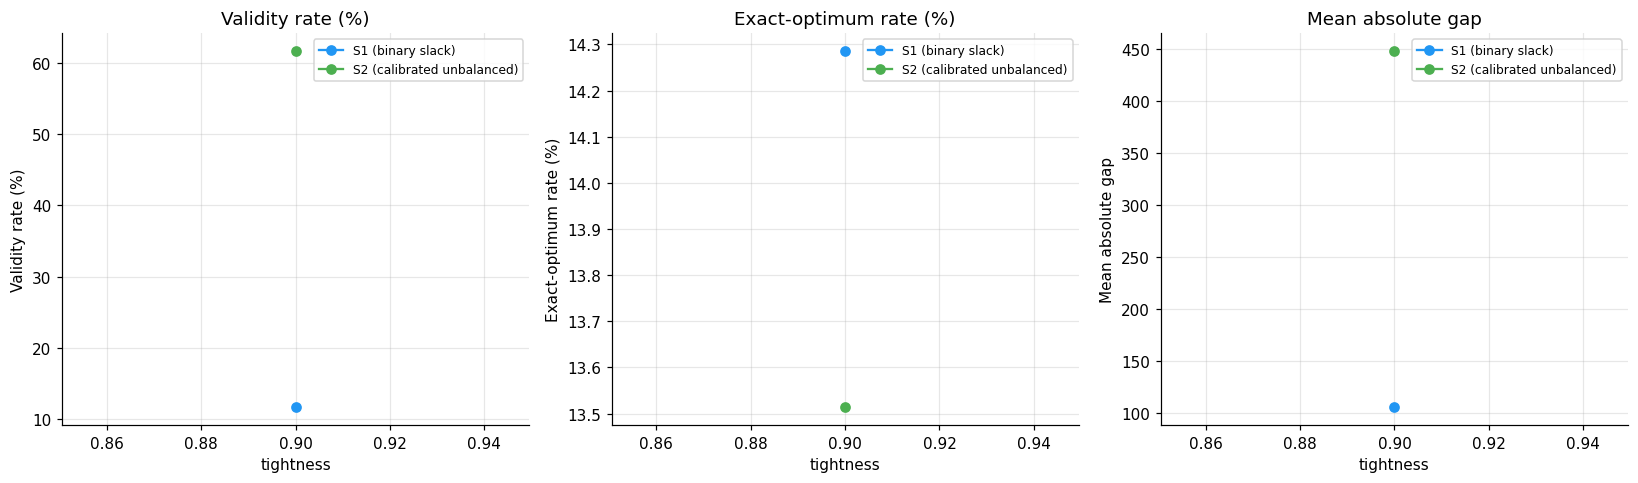

In [5]:
# Visualise the tightness slice -- one panel per metric, one line per solver.
if not tightness_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    metrics = [("Valid %", "Validity rate (%)"),
               ("Optimal %", "Exact-optimum rate (%)"),
               ("Mean abs gap", "Mean absolute gap")]

    for ax, (col, ylab) in zip(axes, metrics):
        for sn in SOLVERS:
            label = SOLVER_LABELS.get(sn, sn)
            sub = tightness_df[tightness_df["Solver"] == label].copy()
            # Skip 'unknown' bucket in the plot
            sub = sub[sub["Tightness"] != "unknown"]
            if sub.empty:
                continue
            x = sub["Tightness"].astype(float)
            ax.plot(x, sub[col], "o-", label=label, color=SOLVER_COLORS.get(sn))
        ax.set_xlabel("tightness")
        ax.set_ylabel(ylab)
        ax.set_title(ylab)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOTS_ROOT / "tightness_slice.png", bbox_inches="tight")
    plt.show()
else:
    print("Skipping tightness plot -- no data.")


## 3. Validity-rate heatmaps

Fraction of replicates per `(n_nodes, n_partitions)` cell where the solver
produced a constraint-satisfying solution.

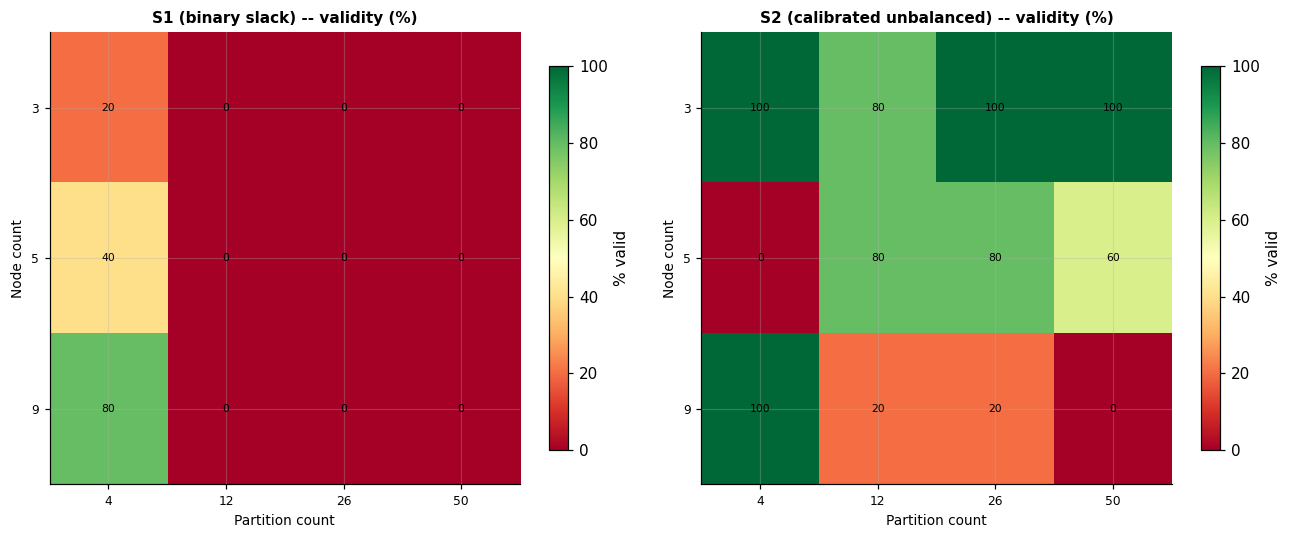

In [6]:
def solver_grid(df, sn, value_col, agg="mean"):
    sub = df[df["solver"] == sn]
    pivot = sub.groupby(["n_nodes", "n_partitions"])[value_col].agg(agg).unstack("n_partitions")
    return pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))


def heatmap(ax, grid, title, fmt=".2f", cmap="RdYlGn", vmin=None, vmax=None, label=""):
    im = ax.imshow(grid.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, fontsize=8)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index, fontsize=8)
    ax.set_xlabel("Partition count", fontsize=9)
    ax.set_ylabel("Node count", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    for r in range(len(grid.index)):
        for c in range(len(grid.columns)):
            v = grid.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, format(v, fmt), ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label=label, shrink=0.85)

# Validity rate heatmap, per solver
fig, axes = plt.subplots(1, len(SOLVERS), figsize=(6*len(SOLVERS), 5), squeeze=False)
for ax, sn in zip(axes[0], SOLVERS):
    grid = solver_grid(df, sn, "valid", agg="mean") * 100
    heatmap(ax, grid, f"{SOLVER_LABELS.get(sn, sn)} -- validity (%)", fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100, label="% valid")
plt.tight_layout()
plt.savefig(PLOTS_ROOT / "validity_heatmap.png", bbox_inches="tight")
plt.show()


## 4. Absolute optimality-gap heatmaps

Mean `cost - ilp_cost` per cell (lower = closer to optimum).  Excludes
instances where either ILP or the solver failed.

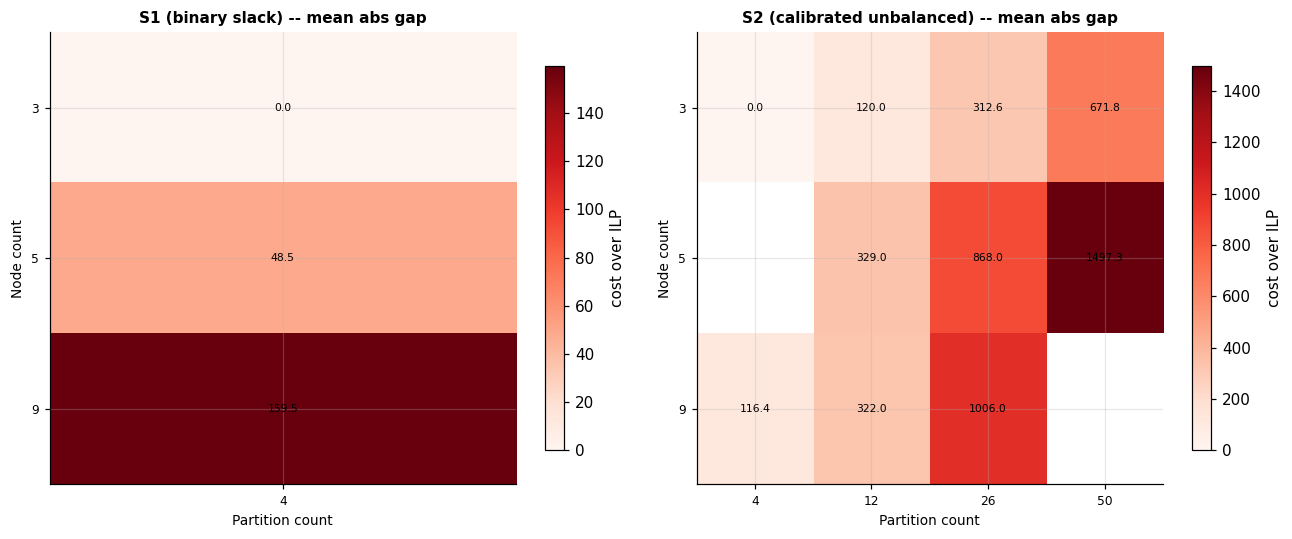

In [7]:
df_valid = df[df["valid"] & df["ilp_valid"]].copy()

fig, axes = plt.subplots(1, len(SOLVERS), figsize=(6*len(SOLVERS), 5), squeeze=False)
for ax, sn in zip(axes[0], SOLVERS):
    sub = df_valid[df_valid["solver"] == sn]
    if sub.empty:
        ax.set_title(f"{SOLVER_LABELS.get(sn, sn)} -- no valid data")
        ax.axis("off")
        continue
    grid = sub.groupby(["n_nodes", "n_partitions"])["gap_abs"].mean().unstack("n_partitions")
    grid = grid.reindex(index=sorted(grid.index), columns=sorted(grid.columns))
    heatmap(ax, grid, f"{SOLVER_LABELS.get(sn, sn)} -- mean abs gap",
            fmt=".1f", cmap="Reds", vmin=0, label="cost over ILP")
plt.tight_layout()
plt.savefig(PLOTS_ROOT / "abs_gap_heatmap.png", bbox_inches="tight")
plt.show()


## 5. BQM size scaling

Variables and quadratic coupling counts vs problem size.
Smaller BQMs need fewer qubits to embed on hardware.
S3, if present, generally has more couplings than S1/S2 because of its linking constraint --
this is the documented negative result and not a defect.

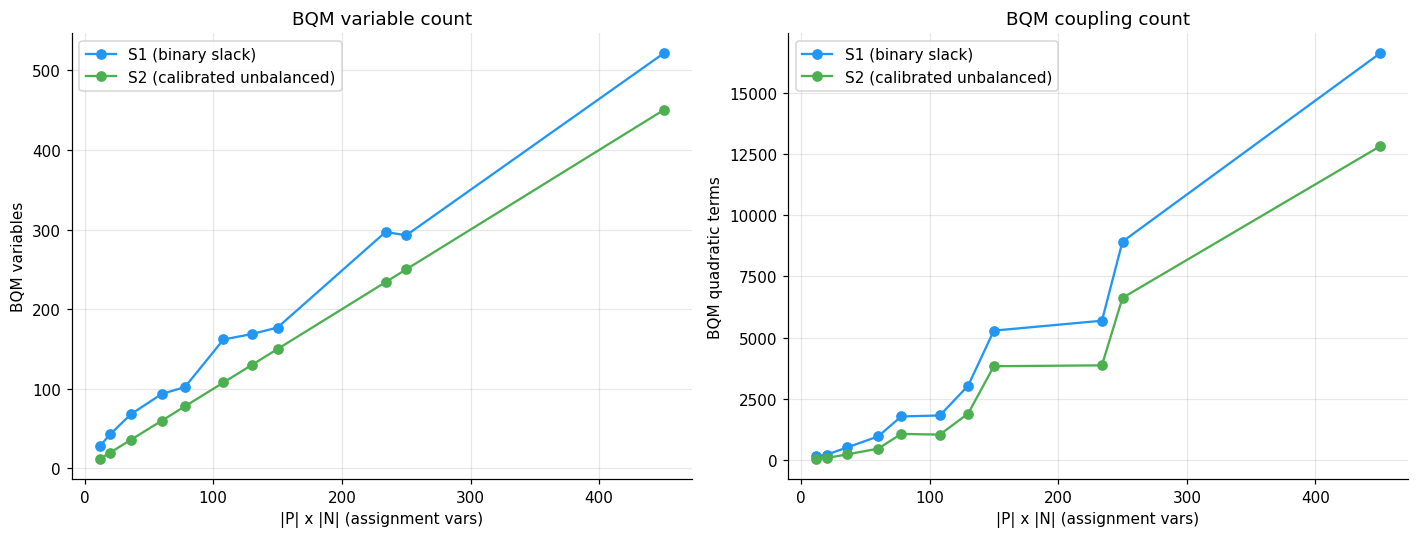

In [8]:
# BQM size is deterministic given (n_nodes, n_partitions, k_safety, capacities),
# so one representative case per cell is enough.

fig, (ax_v, ax_q) = plt.subplots(1, 2, figsize=(13, 5))
for sn in SOLVERS:
    sub = df[df["solver"] == sn].dropna(subset=["bqm_variables", "bqm_interactions"])
    if sub.empty:
        continue
    grouped = sub.groupby("assign_vars").agg(
        bqm_variables=("bqm_variables", "mean"),
        bqm_interactions=("bqm_interactions", "mean"),
    ).reset_index()
    ax_v.plot(grouped["assign_vars"], grouped["bqm_variables"], "o-",
              label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))
    ax_q.plot(grouped["assign_vars"], grouped["bqm_interactions"], "o-",
              label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))

ax_v.set_xlabel("|P| x |N| (assignment vars)")
ax_v.set_ylabel("BQM variables")
ax_v.set_title("BQM variable count")
ax_v.legend()

ax_q.set_xlabel("|P| x |N| (assignment vars)")
ax_q.set_ylabel("BQM quadratic terms")
ax_q.set_title("BQM coupling count")
ax_q.legend()

plt.tight_layout()
plt.savefig(PLOTS_ROOT / "bqm_size.png", bbox_inches="tight")
plt.show()


## 6. Head-to-head: S1 vs S2

Every test case where both S1 and S2 found a valid solution.
Point colour encodes tightness so you can see whether ties
cluster in the loose or tight regime.

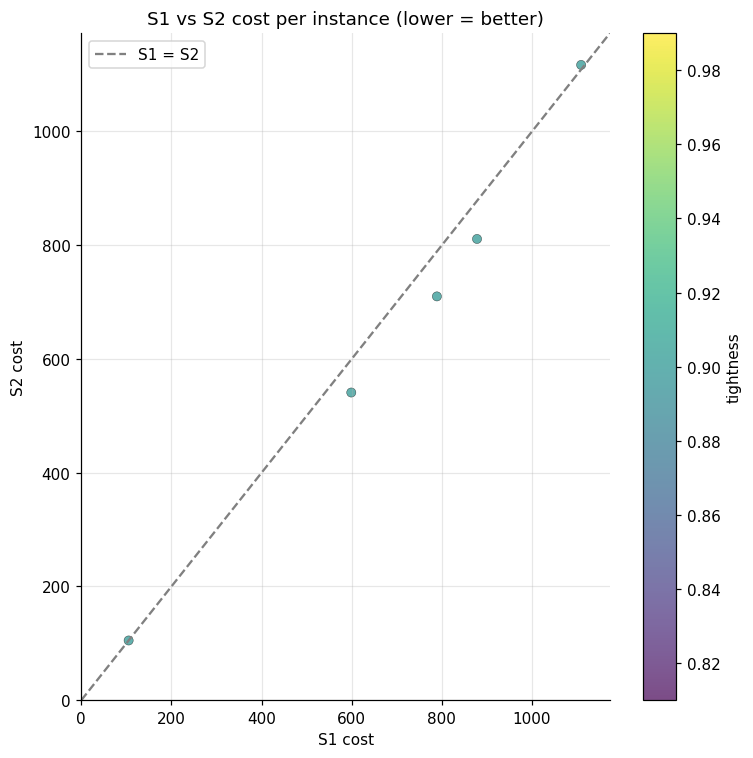

Paired comparison over 5 valid pairs:
  S1 wins: 1    S2 wins: 3    ties: 1


In [9]:
# Pairwise: for every test case where both solvers produced a valid solution,
# plot S2 cost against S1 cost.  Below diagonal = S2 wins.

if "SQA" in SOLVERS and "SQA_SF" in SOLVERS:
    s1 = df[(df["solver"] == "SQA")    & df["valid"]].set_index("key")["cost"]
    s2 = df[(df["solver"] == "SQA_SF") & df["valid"]].set_index("key")["cost"]
    tight = df[df["solver"] == "SQA"].set_index("key")["tightness"]

    common = s1.index.intersection(s2.index)
    pair_df = pd.DataFrame({"S1": s1.loc[common], "S2": s2.loc[common]})
    pair_df["tightness"] = tight.reindex(common).values

    fig, ax = plt.subplots(figsize=(7, 7))
    if pair_df["tightness"].notna().any():
        sc = ax.scatter(pair_df["S1"], pair_df["S2"], c=pair_df["tightness"],
                        cmap="viridis", alpha=0.7, edgecolor="black", linewidth=0.3)
        plt.colorbar(sc, ax=ax, label="tightness")
    else:
        ax.scatter(pair_df["S1"], pair_df["S2"], alpha=0.7)

    lim = max(pair_df["S1"].max(), pair_df["S2"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "--", color="gray", label="S1 = S2")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("S1 cost"); ax.set_ylabel("S2 cost")
    ax.set_title("S1 vs S2 cost per instance (lower = better)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_ROOT / "s1_vs_s2.png", bbox_inches="tight")
    plt.show()

    s1_wins = (pair_df["S1"] < pair_df["S2"]).sum()
    s2_wins = (pair_df["S2"] < pair_df["S1"]).sum()
    ties = (pair_df["S1"] == pair_df["S2"]).sum()
    print(f"Paired comparison over {len(pair_df)} valid pairs:")
    print(f"  S1 wins: {s1_wins}    S2 wins: {s2_wins}    ties: {ties}")
else:
    print("Need both SQA and SQA_SF present for head-to-head.")


## 7. Lambda calibration (S2, S3)

Distribution of `(lambda_1, lambda_2)` picked by `calibrate_lambdas` across
instances.  All-identical bars mean the calibration short-circuited at the
heuristic fallback -- usually because the instance was too big for the
ExactSolver-based search.

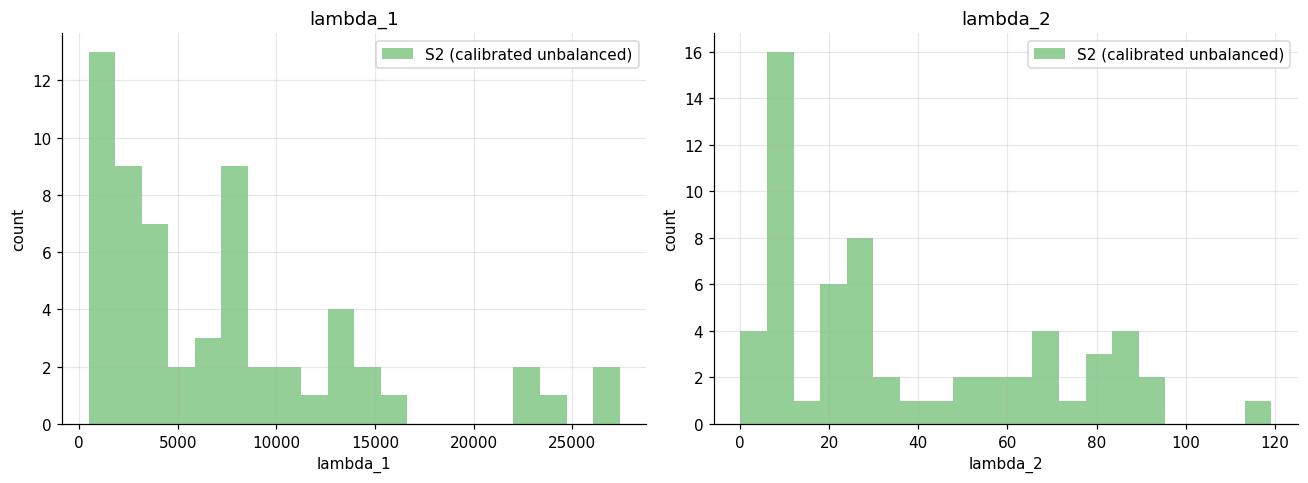

In [10]:
# Distribution of calibrated (lambda_1, lambda_2) used by S2 (and S3 if present).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for sn in SOLVERS:
    sub = df[df["solver"] == sn].dropna(subset=["lambda_1", "lambda_2"])
    if sub.empty:
        continue
    axes[0].hist(sub["lambda_1"], bins=20, alpha=0.6,
                 label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))
    axes[1].hist(sub["lambda_2"], bins=20, alpha=0.6,
                 label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))
axes[0].set_xlabel("lambda_1"); axes[0].set_ylabel("count"); axes[0].set_title("lambda_1")
axes[1].set_xlabel("lambda_2"); axes[1].set_ylabel("count"); axes[1].set_title("lambda_2")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.savefig(PLOTS_ROOT / "lambda_distribution.png", bbox_inches="tight")
plt.show()


## 8. Constraint-violation breakdown

For solutions flagged `valid=False`, distinguish k-safety violations
(wrong number of copies per partition) from capacity overruns (node
load exceeded).  A solver that's invalid only via k-safety has a
different problem from one that's invalid via storage.

In [11]:
# Breakdown of constraint violations for *invalid* solutions, by solver.
viol = df[~df["valid"]].copy()
if viol.empty:
    print("Every solver produced valid solutions on every case -- no violation breakdown.")
else:
    summary_v = viol.groupby("solver").agg(
        n_invalid=("valid", "size"),
        mean_k_safety_violations=("k_safety_violations", "mean"),
        mean_capacity_overruns=("capacity_overruns", "mean"),
    ).rename(index=SOLVER_LABELS)
    print(summary_v)


                            n_invalid  mean_k_safety_violations  \
solver                                                            
S1 (binary slack)                  53                 12.056604   
S2 (calibrated unbalanced)         23                  0.217391   

                            mean_capacity_overruns  
solver                                              
S1 (binary slack)                         0.037736  
S2 (calibrated unbalanced)                1.391304  


## Conclusions

The arbitrary-partition runner exercises both S1 and S2 with variable
partition sizes (`size_p` varies per partition rather than being fixed
to 1).  After the Phase-2 fix, S2 handles `size_p` explicitly in its
storage penalty, so the comparison is now apples-to-apples with S1 here
the same way it is in the unit-partition runner.

Specifically check:

1. **How much harder is the arbitrary case for both SQA variants?**  The
   storage constraint has more structure (bin-packing-like) when sizes
   vary, so expect higher absolute gaps relative to ILP than the unit
   case shows.

2. **Does the S1-vs-S2 ranking flip when sizes vary?**  Variable sizes
   make S2's quadratic coefficients between assignment variables larger
   (they scale with `size_p * size_p'`), which can change the energy
   landscape's curvature.  If S2 dominated unit but ties or loses on
   arbitrary, that's worth flagging.

3. **Tightness interaction.**  High tightness with variable sizes is
   the hardest regime -- it's essentially a bin-packing instance.
   Compare validity rates at `tightness=0.9` against `tightness=0.3`
   for both solvers.

4. **Feasibility-probe retries.**  If many cases failed the generator's
   ILP probe, the test bank may be smaller than expected at high
   tightness.  Check the row count per tightness bucket.


## Empirical Findings (ArbitraryExperiment_2.json, tightness = 0.9)

Numbers in this section are computed from the 60 cases in
`ArbitraryExperiment_2.json`.  Every case uses `tc_tightness = 0.9`
with variable partition sizes -- the hard regime for both encodings.
Comparisons against the unit-partition results are confounded by the
tightness change (unit file is 0.7, this file is 0.9), so any
cross-file claim is jointly about size variation *and* tightness.

### 1. The hard regime breaks S1, and S2 only partially holds together

- **S1 (binary slack) collapses.**  Validity drops to 11.7% (7/60);
  exact-optimum rate is 1.7% (1/60).  Across 12 `(n_nodes, n_partitions)`
  cells, S1 is at 0% validity in 8 of them.  Mean k-safety violations
  on its 53 invalid cases is 12.06 -- these are not near-feasible
  solutions, the encoding is simply not converging on the partition-
  count constraint when capacities are tight and sizes vary.
- **S2 holds together better.**  Validity is 61.7% (37/60), optimal
  is 8.3% (5/60).  S2 beats S1 on validity in 11 of 12 cells.

But "S2 wins" only as a binary feasibility question.  On *cost*, S2's
mean relative gap among valid solutions is 0.636 -- the average S2
solution is over 60% more expensive than ILP's, with a worst case
243% over.  The right reading is: **S2 finds feasible-but-mediocre
assignments where S1 finds nothing at all.**

### 2. The head-to-head is uninformative on this file

Only 5 cases produced a valid solution from both encodings.  Among
those, S2 wins 3, S1 wins 1, tied 1 -- too small a sample to support
a real ranking.  The interesting comparison here isn't head-to-head
on cost; it's the asymmetry in "only one was valid":

| Outcome              | Count |
|----------------------|-------|
| Only S1 valid        |  2    |
| Only S2 valid        | 32    |
| Both valid           |  5    |
| Both invalid         | 21    |

S2 is dramatically more likely to be the *only* solver that produces
any feasible answer at all in this regime.

### 3. Failure modes are now diagnostic

The invalid-breakdown numbers tell a sharper story than they did at
tightness 0.7:

- **S1 invalid (53 cases):** mean 12.06 k-safety violations,
  mean 0.04 capacity overruns.  S1 is hitting the partition-count
  constraint, hard, on essentially every failed case.
- **S2 invalid (23 cases):** mean 0.22 k-safety violations,
  mean 1.39 capacity overruns.  S2's calibrated `lambda_2` is
  under-penalising node load at this tightness -- its remaining
  failures are over-capacity rather than wrong-count.

If you were to invest in fixing one encoding for this regime, the
diagnoses point in different directions: S1 needs its k-safety penalty
strengthened (or a different slack-variable structure for the partition
constraint); S2 needs `calibrate_lambdas` to push `lambda_2` higher in
the tight-capacity, variable-size regime.

### 4. Spatial pattern across (n_nodes, n_partitions) cells

S1's only non-zero cells are `n=3, p=4` (20%), `n=5, p=4` (40%),
`n=9, p=4` (80%).  In other words S1 has a chance only at the
smallest partition count, and only some of the time -- the moment
partition counts grow, S1 is at 0% validity uniformly.

S2 maintains 100% validity at `n=3, p={4, 26, 50}` and at `n=9, p=4`,
80% at most other small/medium cells, and drops to 0--20% only at
`n=5, p=4` (interestingly, the *one* cell where S1 still has some
chance) and at `n=9, p={26, 50}`.  The largest-grid cell
(`n=9, p=50`) breaks S2 too -- 0% validity there for both encodings.

### 5. Lambda calibration is varied, but apparently miscalibrated

S2's calibration produced 59 unique `lambda_1` and 59 unique
`lambda_2` values across 60 instances.  So the calibrator is
exercising its per-instance search -- the failures are not "the
calibrator gave up and used the heuristic fallback."  Yet the failures
that do happen are dominated by capacity overruns, which means the
*objective* the calibrator is optimising for is not catching the
right `lambda_2` at high tightness with variable sizes.  This is a
concrete pointer for follow-up work on `calibrate_lambdas`.

### Takeaways

On arbitrary-partition instances at tightness 0.9:

1. **Neither SQA encoding is solving the problem in a usable way.**
   Best case is S2 at 8.3% optimal and 64% mean relative gap.  ILP
   solves these instances exactly; on this regime the SQA encodings
   are not a viable substitute.
2. **S2 is meaningfully more robust on feasibility than S1.**  Where
   you previously had a closely matched pair, you now have one
   encoding that returns assignments and one that mostly returns
   nothing.  The reason is structural -- variable partition sizes
   make S1's binary slack constraint substantially harder to satisfy,
   while S2 absorbs the size variation into its quadratic capacity
   penalty.
3. **The failure-mode split is reproducible and diagnostic.**
   S1 fails by violating partition counts, S2 by overrunning
   capacity, exactly as their formulations predict.  The relative
   counts (12.06 vs. 1.39) sharpen the same pattern that was barely
   visible at tightness 0.7.
4. **The cost story is unchanged: ILP wins, and by a lot.**  S2 is
   the right SQA choice here only if you've already accepted that
   you cannot use ILP -- not because S2 is good, but because it is
   the only encoding that returns answers at all.

What this file does *not* establish: behaviour at other tightness
values (this is again a single-tightness slice), any S3 comparison
(not enabled), or whether the unit-vs-arbitrary gap is driven by
size variation, by tightness, or by both jointly (it would take a
paired sweep across `(tightness, size_p_variable)` to separate them).
